# System Fender DAF

Total fender force DAF: peak of summed active fenders divided by sum of static forces.
Provides context but is less conservative than the individual fender DAF.

In [1]:
import os, glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from pathlib import Path

HEADINGS       = ['0deg', '45deg', '90deg', '135deg', '180deg']
HEADING_LABELS = {'0deg': '0°', '45deg': '45°', '90deg': '90°',
                  '135deg': '135°', '180deg': '180°'}
# Resolve this notebook's folder (works in VS Code and standard Jupyter)
NOTEBOOK_DIR   = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / '_')).parent
os.chdir(NOTEBOOK_DIR)
import sys
sys.path.insert(0, str(NOTEBOOK_DIR))
from thesis_style import apply, full, save
apply()
print(f'Working directory: {Path.cwd()}')

In [2]:
g         = 9.81
N_COND    = 10
HS_VALUES = np.linspace(0.5, 3.5, N_COND)

_B = 'BerthedTanker_Catenary'
LINES = {
    'HL7':  {'n':  7,'base':f'{_B}/Run1', 'static':'HL7/StaticResults_HL7_run1-1.h5',    'dynamic':'HL7/DynamicResults_HL7_run1-1.h5',    'lw':7.0,'label':'$H/\\lambda = 1/7$',  'n_cond':9},
    'HL9':  {'n':  9,'base':f'{_B}/Run2', 'static':'HL9/StaticResults_HL9_run2-1.h5',    'dynamic':'HL9/DynamicResults_HL9_run2-1.h5',    'lw':6.5,'label':'$H/\\lambda = 1/9$',  'n_cond':9},
    'HL11': {'n': 11,'base':f'{_B}/Run3', 'static':'HL11/StaticResults_HL11_run3-1.h5',  'dynamic':'HL11/DynamicResults_HL11_run3-1.h5',  'lw':6.0,'label':'$H/\\lambda = 1/11$', 'n_cond':9},
    'HL13': {'n': 13,'base':f'{_B}/Run4', 'static':'HL13/StaticResults_HL13_run4-1.h5',  'dynamic':'HL13/DynamicResults_HL13_run4-1.h5',  'lw':5.5,'label':'$H/\\lambda = 1/13$', 'n_cond':9},
    'HL15': {'n': 15,'base':f'{_B}/Run5', 'static':'HL15/StaticResults_HL15_run5-1.h5',  'dynamic':'HL15/DynamicResults_HL15_run5-1.h5',  'lw':5.0,'label':'$H/\\lambda = 1/15$', 'n_cond':9},
    'HL17': {'n': 17,'base':f'{_B}/Run6', 'static':'HL17/StaticResults_HL17_run6-1.h5',  'dynamic':'HL17/DynamicResults_HL17_run6-1.h5',  'lw':4.5,'label':'$H/\\lambda = 1/17$', 'n_cond':9},
    'HL19': {'n': 19,'base':f'{_B}/Run7', 'static':'HL19/StaticResults_HL19_run7-1.h5',  'dynamic':'HL19/DynamicResults_HL19_run7-1.h5',  'lw':4.0,'label':'$H/\\lambda = 1/19$', 'n_cond':9},
    'HL21': {'n': 21,'base':f'{_B}/Run8', 'static':'HL21/StaticResults_HL21_run8-1.h5',  'dynamic':'HL21/DynamicResults_HL21_run8-1.h5',  'lw':3.5,'label':'$H/\\lambda = 1/21$', 'n_cond':9},
    'HL23': {'n': 23,'base':f'{_B}/Run9', 'static':'HL23/StaticResults_HL23_run9-1.h5',  'dynamic':'HL23/DynamicResults_HL23_run9-1.h5',  'lw':3.2,'label':'$H/\\lambda = 1/23$', 'n_cond':9},
    'HL25': {'n': 25,'base':f'{_B}/Run10','static':'HL25/StaticResults_HL25_run10-1.h5', 'dynamic':'HL25/DynamicResults_HL25_run10-1.h5', 'lw':2.9,'label':'$H/\\lambda = 1/25$', 'n_cond':8},
    'HL27': {'n': 27,'base':f'{_B}/Run11','static':'HL27/StaticResults_HL27_run11-1.h5', 'dynamic':'HL27/DynamicResults_HL27_run11-1.h5', 'lw':2.6,'label':'$H/\\lambda = 1/27$', 'n_cond':7},
    'HL29': {'n': 29,'base':f'{_B}/Run12','static':'HL29/StaticResults_HL29_run12-1.h5', 'dynamic':'HL29/DynamicResults_HL29_run12-1.h5', 'lw':2.3,'label':'$H/\\lambda = 1/29$', 'n_cond':7},
}
MOORING_ELEMS = [f'Mooring{i}' for i in range(1, 9)]
FENDER_ELEMS  = [f'Fender{i}'  for i in range(1, 7)]
TRANSIENT_IDX = int(400 / 0.5)

for cfg in LINES.values():
    nc      = cfg['n_cond']
    Hs_vals = HS_VALUES[:nc]
    Tp_vals = np.sqrt(Hs_vals * 2 * np.pi * cfg['n'] / g)
    cfg['cond_params'] = {
        i+1: (round(float(hs),2), round(float(tp),2))
        for i,(hs,tp) in enumerate(zip(Hs_vals, Tp_vals))
    }

def _resolve_paths(heading, cfg):
    s_nested = f'{heading}/{cfg["static"]}'
    if os.path.exists(s_nested):
        return s_nested, f'{heading}/{cfg["dynamic"]}'.rsplit('-', 1)[0]
    fname_s = cfg['static'].split('/', 1)[1]
    fname_d = cfg['dynamic'].split('/', 1)[1].rsplit('-', 1)[0]
    return f'{heading}/{fname_s}', f'{heading}/{fname_d}'

In [3]:
STATIC_THRESHOLD_KN = 1.0
sys_rows = []
for heading in HEADINGS:
    print('=== ' + heading + ' ===')
    for line_name, cfg in LINES.items():
        static_path, dyn_base = _resolve_paths(heading, cfg)
        dyn_files   = sorted(glob.glob(f'{dyn_base}-*.h5'),
                             key=lambda p: int(p.rsplit('-',1)[-1].replace('.h5','')))
        run_key = cfg['base'].split('/')[-1]
        static_by_cond = {}
        try:
            with h5py.File(static_path,'r') as fs:
                base = f'{list(fs.keys())[0]}/{run_key}'
                for ck in fs[base].keys():
                    n = int(ck.split('_')[-1])
                    grp = fs[f'{base}/{ck}/Static/Tanker']
                    static_by_cond[n] = {fdr: float(grp[f'{fdr}/FTotal'][()])/1e3
                                         for fdr in FENDER_ELEMS if f'{fdr}/FTotal' in grp}
        except FileNotFoundError:
            continue
        if not dyn_files: continue
        print(f'  {line_name}: {len(dyn_files)} seed(s)')
        seed_sys_max = {n: [] for n in static_by_cond}
        for dyn_file in dyn_files:
            try:
                with h5py.File(dyn_file,'r') as fd:
                    base_d = f'{list(fd.keys())[0]}/{run_key}'
                    for ck in fd[base_d].keys():
                        n = int(ck.split('_')[-1])
                        if n not in seed_sys_max: continue
                        grp = fd[f'{base_d}/{ck}/Dynamic/Tanker/Positioning system force']
                        sum_ts = None
                        for fdr in FENDER_ELEMS:
                            s_f = static_by_cond[n].get(fdr, np.nan)
                            if not np.isnan(s_f) and abs(s_f) > STATIC_THRESHOLD_KN:
                                try:
                                    ts = np.abs(grp[f'TotalForce_{fdr}'][:] / 1e3)
                                    sum_ts = ts if sum_ts is None else sum_ts + ts
                                except KeyError: pass
                        if sum_ts is not None:
                            seed_sys_max[n].append(float(np.max(sum_ts)))
            except FileNotFoundError: pass
        for n, fdr_s in static_by_cond.items():
            hs, tp = cfg['cond_params'].get(n,(np.nan,np.nan))
            active = [abs(v) for v in fdr_s.values()
                      if not np.isnan(v) and abs(v) > STATIC_THRESHOLD_KN]
            val = float(np.max(seed_sys_max[n])) / sum(active) \
                  if seed_sys_max[n] and active else np.nan
            sys_rows.append({'heading':heading,'line':line_name,'cond_num':n,
                             'Hs':hs,'Tp':tp,'sys_DAF':val})

df_sys = pd.DataFrame(sys_rows)
print(f'Total rows: {len(df_sys)}')

=== 0deg ===
  HL7: 5 seed(s)


  HL9: 5 seed(s)


  HL11: 5 seed(s)


  HL13: 5 seed(s)


  HL15: 5 seed(s)


...

  HL23: 5 seed(s)


  HL25: 5 seed(s)


  HL27: 5 seed(s)


  HL29: 5 seed(s)


Total rows: 515


## Scatter — System Fender DAF

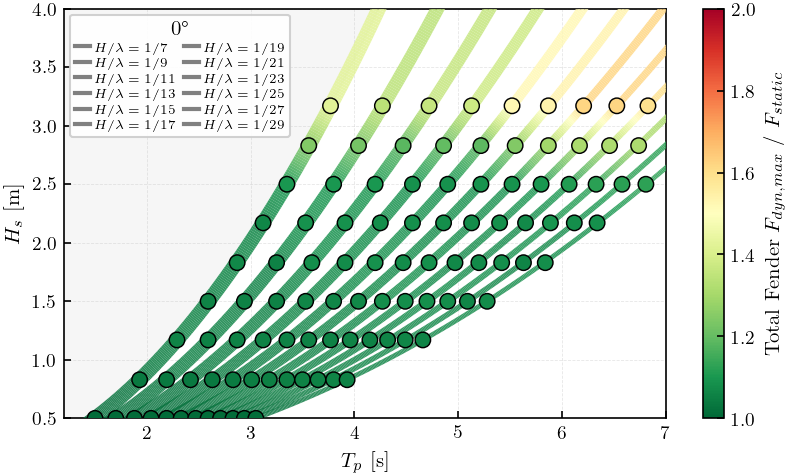

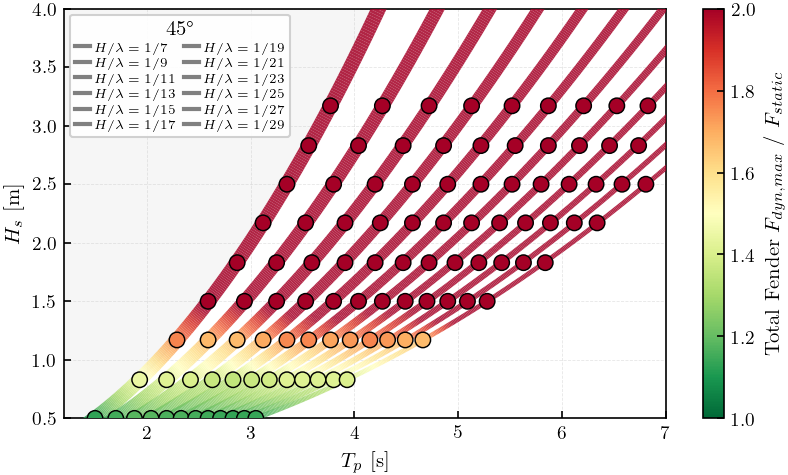

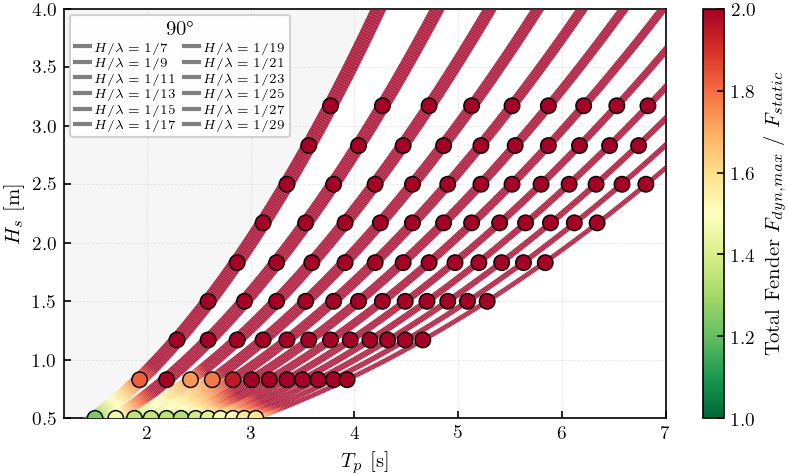

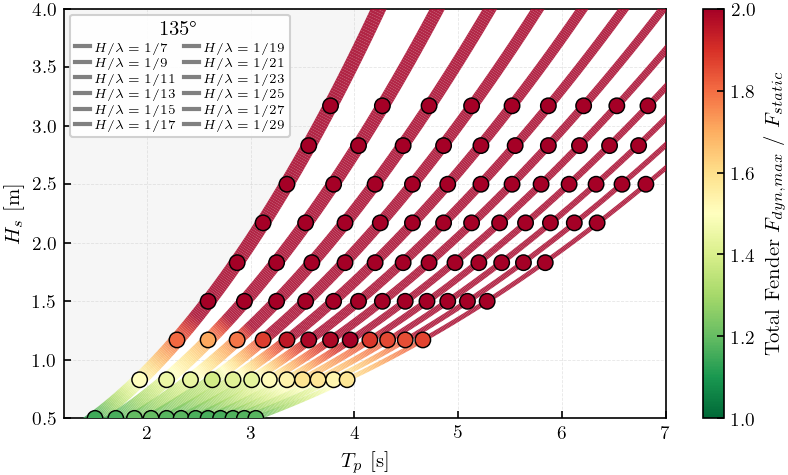

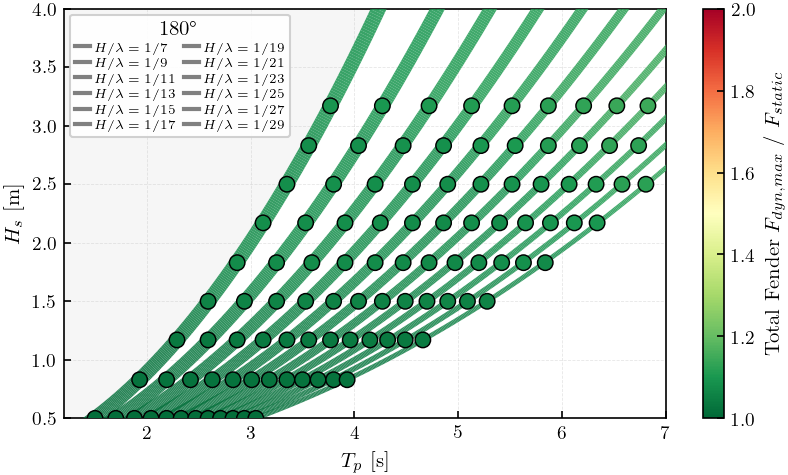

In [4]:
DAF_CMAP_MAX = 2.0
norm = Normalize(vmin=1.0, vmax=DAF_CMAP_MAX, clip=True)

def make_lc(x, y, daf_arr, lw):
    pts  = np.array([x, y]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap='RdYlGn_r', norm=norm,
                          linewidth=lw, alpha=0.85, zorder=3)
    lc.set_array((daf_arr[:-1] + daf_arr[1:]) / 2)
    return lc

legend_handles = [plt.Line2D([0],[0], color='grey', lw=2.0, label=cfg['label'])
                  for cfg in LINES.values()]
_leg_kw = dict(fontsize=6, ncol=2, handlelength=1.2, columnspacing=0.6,
               handletextpad=0.4, borderpad=0.4, labelspacing=0.25)

def draw_panel(ax, heading):
    sub_h = df_sys[df_sys.heading == heading]
    sweep = np.linspace(0.3, 7.5, 600)
    ax.fill_between(sweep, g*sweep**2/(2*np.pi*7), 10,
                    color='lightgrey', alpha=0.2, zorder=0)
    sc_ref = None
    for line_name, cfg in LINES.items():
        y_curve = g*sweep**2/(2*np.pi*cfg['n'])
        sub      = sub_h[sub_h.line == line_name]
        daf_dict = dict(zip(sub.cond_num, sub['sys_DAF']))
        conds    = sorted(cfg['cond_params'])
        pts_x    = np.array([cfg['cond_params'][c][1] for c in conds])
        pts_y    = np.array([cfg['cond_params'][c][0] for c in conds])
        daf_pts  = np.array([daf_dict.get(c, np.nan) for c in conds])
        daf_interp = np.interp(sweep,
                               np.concatenate([[sweep[0]], pts_x]),
                               np.concatenate([[1.0], daf_pts]))
        ax.add_collection(make_lc(sweep, y_curve, daf_interp, cfg['lw']))
        sc = ax.scatter(pts_x, pts_y, c=daf_pts, cmap='RdYlGn_r', norm=norm,
                        s=55, zorder=5, edgecolors='black', linewidths=0.7)
        if sc_ref is None: sc_ref = sc
    ax.set_xlabel('$T_p$ [s]'); ax.set_ylabel('$H_s$ [m]')
    ax.set_xlim(1.2,7.0); ax.set_ylim(0.5,4.0)
    ax.grid(True, alpha=0.3)
    return sc_ref

for h in HEADINGS:
    fig, ax = plt.subplots(figsize=full())
    sc_ref = draw_panel(ax, h)
    ax.legend(handles=legend_handles, loc='upper left', **_leg_kw, title=f'{HEADING_LABELS[h]}')
    cb = plt.colorbar(sc_ref, ax=ax)
    cb.set_label(r'Total Fender $F_{dyn,max}$ / $F_{static}$')
    plt.tight_layout(); save(fig, f'daf_fender_sys_{h}'); plt.show()

## Heatmap — System Fender DAF

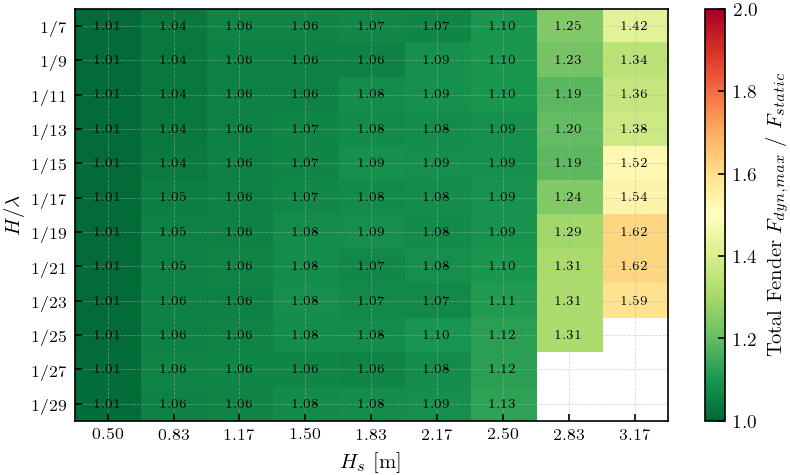

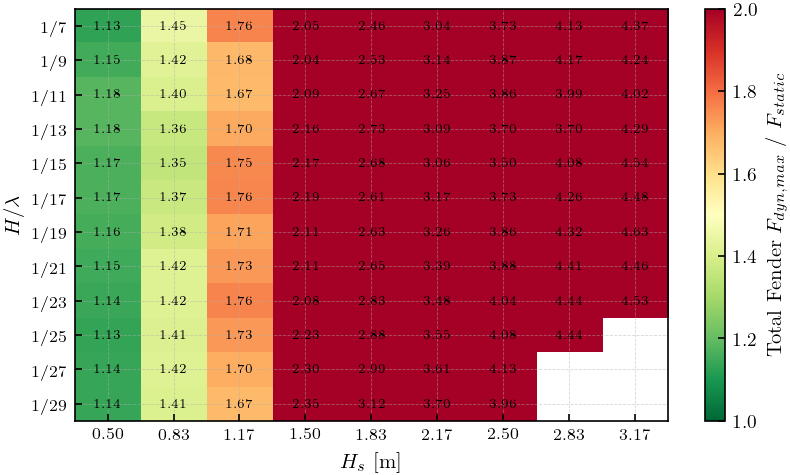

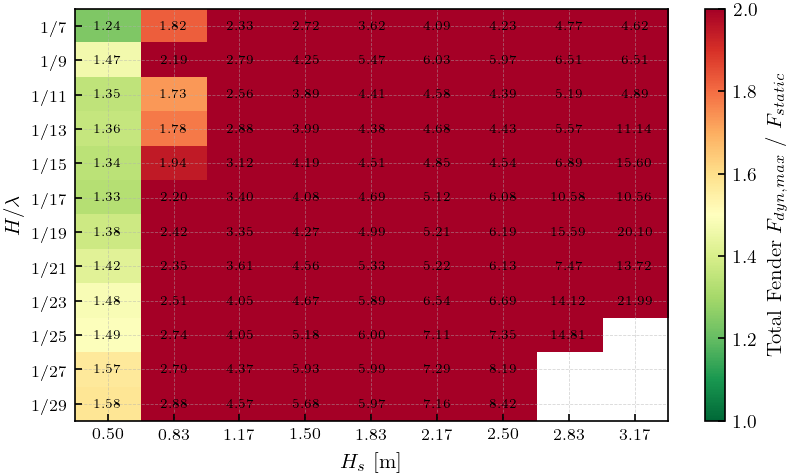

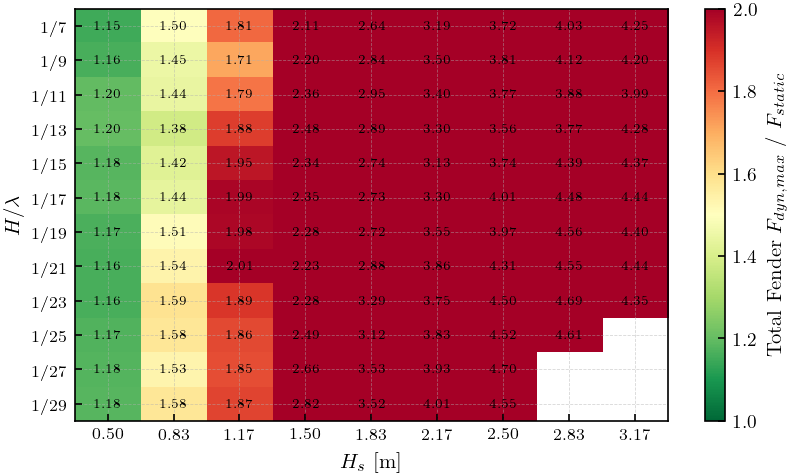

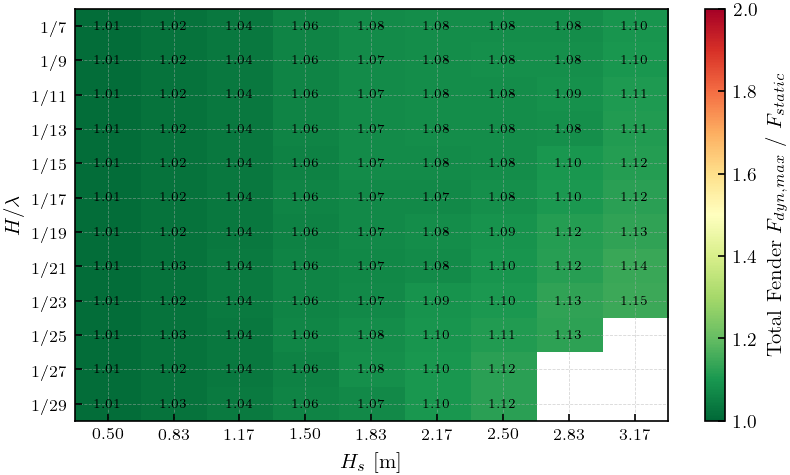

In [5]:
line_order = list(LINES.keys())
max_cond   = max(cfg['n_cond'] for cfg in LINES.values())
vmin, vmax = 1.0, 2.0

for h in HEADINGS:
    fig, ax = plt.subplots(figsize=full())
    sub_h = df_sys[df_sys.heading == h]
    mat = np.full((len(line_order), max_cond), np.nan)
    for r, ln in enumerate(line_order):
        for row in sub_h[sub_h.line == ln].itertuples():
            c = row.cond_num - 1
            if c < max_cond: mat[r,c] = row.sys_DAF
    im = ax.imshow(mat, aspect='auto', vmin=vmin, vmax=vmax,
                   cmap=plt.cm.RdYlGn_r, origin='upper', interpolation='none')
    ax.set_xticks(range(max_cond))
    ax.set_xticklabels([f'{HS_VALUES[i]:.2f}' for i in range(max_cond)], fontsize=8)
    ax.set_yticks(range(len(line_order))); ax.set_yticklabels(['$' + LINES[ln]['label'].split('= ')[1] for ln in line_order], fontsize=8)
    ax.set_xlabel('$H_s$ [m]'); ax.set_ylabel(r'$H/\lambda$')
    for r in range(len(line_order)):
        for c in range(max_cond):
            v = mat[r,c]
            if not np.isnan(v):
                ax.text(c, r, f'{v:.2f}', ha='center', va='center',
                        fontsize=6, color='black')
    cb = plt.colorbar(im, ax=ax)
    cb.set_label(r'Total Fender $F_{dyn,max}$ / $F_{static}$')
    plt.tight_layout(); save(fig, f'daf_fender_sys_heatmap_{h}'); plt.show()